# Partie III — RNN, LSTM, GRU et Seq2Seq
## Projet de fin de module — Deep Learning (EMSI Casablanca, 2025–2026)

**Thème :** Modélisation de séquences et traduction automatique sur données textuelles réelles.

**Dataset :** Tatoeba fra-eng — paires de phrases anglais-français (filtré à ≤10 tokens).

**Objectifs :**
- Comprendre les modèles de langage (perplexité, factorisation de probabilités)
- Implémenter et comparer RNN, LSTM, GRU
- Illustrer le BPTT et l'effet du gradient clipping
- Construire un système Seq2Seq complet (encodeur GRU + décodeur conditionnel)
- Comparer décodage glouton et beam search
- Évaluer avec le score BLEU


---
## 1. Fondements Théoriques

### 1.1 Modèles de Langage

Un **modèle de langage** assigne une probabilité à une séquence de tokens $(x_1, x_2, \ldots, x_T)$.

Par la règle de chaîne :

$$P(x_1, \ldots, x_T) = \prod_{t=1}^{T} P(x_t \mid x_1, \ldots, x_{t-1})$$

L'objectif est donc d'apprendre à prédire le **prochain token** à partir du contexte passé.

### 1.2 Perplexité

La **perplexité** mesure la qualité d'un modèle de langage :

$$\text{PPL} = \exp\left(-\frac{1}{T}\sum_{t=1}^{T}\log P(x_t \mid x_{<t})\right) = \exp(\text{CE})$$

- PPL faible → le modèle prédit bien le prochain token (confiant et correct)
- PPL ≈ 1 → modèle parfait ; PPL ≈ |V| (taille vocabulaire) → modèle aléatoire

### 1.3 Architectures Récurrentes

#### RNN Simple
$$h_t = \tanh(W_x x_t + W_h h_{t-1} + b)$$

**Problème :** gradient évanescent/explosif sur longues séquences (chaîne de produits de Jacobiens).

#### LSTM (Long Short-Term Memory)
Introduit un **état de cellule** $c_t$ et trois portes :

$$f_t = \sigma(W_f [h_{t-1}, x_t] + b_f)\quad \text{(oubli)}$$
$$i_t = \sigma(W_i [h_{t-1}, x_t] + b_i)\quad \text{(entrée)}$$
$$\tilde{c}_t = \tanh(W_c [h_{t-1}, x_t] + b_c)$$
$$c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t$$
$$o_t = \sigma(W_o [h_{t-1}, x_t] + b_o),\quad h_t = o_t \odot \tanh(c_t)$$

#### GRU (Gated Recurrent Unit)
Simplifie le LSTM avec seulement **deux portes** :

$$z_t = \sigma(W_z [h_{t-1}, x_t])\quad \text{(mise à jour)}$$
$$r_t = \sigma(W_r [h_{t-1}, x_t])\quad \text{(réinitialisation)}$$
$$\tilde{h}_t = \tanh(W [r_t \odot h_{t-1}, x_t])$$
$$h_t = z_t \odot h_{t-1} + (1 - z_t) \odot \tilde{h}_t$$

### 1.4 Tableau Comparatif

| Critère | RNN | LSTM | GRU |
|---------|-----|------|-----|
| Portes | 0 | 3 (oubli, entrée, sortie) | 2 (mise à jour, réinitialisation) |
| État mémoire | $h_t$ | $h_t + c_t$ | $h_t$ |
| Gradient | Évanescent | Stable (chemin via $c_t$) | Stable (compromis) |
| Paramètres | Peu | Plus | Moins que LSTM |
| Usage | Séquences courtes | Longues dépendances | Bon compromis |


---
## 2. Imports et Configuration

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, re, time, math, random, zipfile, unicodedata
import requests

try:
    from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
    import nltk
    nltk.download("punkt", quiet=True)
    BLEU_AVAILABLE = True
except ImportError:
    BLEU_AVAILABLE = False
    print("nltk non disponible — évaluation BLEU désactivée")

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch : {torch.__version__} | Device : {DEVICE}")

os.makedirs("models",  exist_ok=True)
os.makedirs("data",    exist_ok=True)
os.makedirs("figures", exist_ok=True)
plt.style.use("seaborn-v0_8-whitegrid")


PyTorch : 2.12.1+cpu | Device : cpu


---
## 3. Préparation des Données Tatoeba fra-eng

In [ ]:
# Téléchargement du corpus Tatoeba (fra-eng) depuis manythings.org
DATA_ZIP  = "data/fra-eng.zip"
DATA_FILE = "data/fra.txt"

if not os.path.exists(DATA_FILE):
    print("Téléchargement du corpus Tatoeba fra-eng...")
    url = "https://www.manythings.org/anki/fra-eng.zip"
    try:
        r = requests.get(url, timeout=60)
        with open(DATA_ZIP, "wb") as f:
            f.write(r.content)
        with zipfile.ZipFile(DATA_ZIP, "r") as z:
            z.extractall("data/")
        print(f"Corpus téléchargé : {os.path.getsize(DATA_FILE) // 1024} Ko")
    except Exception as e:
        print(f"Erreur de téléchargement : {e}")
        print("Utilisation d'un mini-corpus de démonstration...")
        demo_pairs = [
            "I am cold.\tJ ai froid .\tCC-BY 2.0",
            "I am hot.\tJ ai chaud .\tCC-BY 2.0",
            "He is tall.\tIl est grand .\tCC-BY 2.0",
            "She is kind.\tElle est gentille .\tCC-BY 2.0",
            "We are here.\tNous sommes ici .\tCC-BY 2.0",
            "They are late.\tIls sont en retard .\tCC-BY 2.0",
            "I love you.\tJe t aime .\tCC-BY 2.0",
            "I am tired.\tJe suis fatigue .\tCC-BY 2.0",
            "How are you ?\tComment allez-vous ?\tCC-BY 2.0",
            "Good morning.\tBonjour .\tCC-BY 2.0",
        ] * 500  # répété pour avoir assez de données
        with open(DATA_FILE, "w", encoding="utf-8") as f:
            f.write("\n".join(demo_pairs))
else:
    print(f"Corpus déjà présent : {os.path.getsize(DATA_FILE) // 1024} Ko")


Téléchargement du corpus Tatoeba fra-eng...
Erreur de téléchargement : File is not a zip file
Utilisation d'un mini-corpus de démonstration...


In [ ]:
def normalize_string(s):
    """Normalisation : minuscules, suppression accents, marquage ponctuation."""
    s = s.lower().strip()
    s = ''.join(c for c in unicodedata.normalize('NFD', s)
                if unicodedata.category(c) != 'Mn')
    s = re.sub(r"([.!?])", r" \1", s)
    s = re.sub(r"[^a-zA-Z.!? ]+", r" ", s)
    return s.strip()

def load_pairs(filepath, max_len=10, max_pairs=30000):
    """Charge et filtre les paires (anglais, français) du corpus Tatoeba."""
    pairs = []
    with open(filepath, encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split("\t")
            if len(parts) < 2:
                continue
            eng = normalize_string(parts[0])
            fra = normalize_string(parts[1])
            if len(eng.split()) <= max_len and len(fra.split()) <= max_len:
                if len(eng) > 0 and len(fra) > 0:
                    pairs.append((eng, fra))
            if len(pairs) >= max_pairs:
                break
    return pairs

pairs = load_pairs(DATA_FILE)
random.shuffle(pairs)
print(f"Paires chargées (≤10 tokens) : {len(pairs):,}")
print("\nExemples :")
for eng, fra in pairs[:5]:
    print(f"  EN: {eng}")
    print(f"  FR: {fra}")
    print()


Paires chargées (≤10 tokens) : 5,000

Exemples :
  EN: she is kind .
  FR: elle est gentille  .

  EN: i am hot .
  FR: j ai chaud  .

  EN: i am hot .
  FR: j ai chaud  .

  EN: we are here .
  FR: nous sommes ici  .

  EN: we are here .
  FR: nous sommes ici  .



In [ ]:
class Vocab:
    """Vocabulaire avec tokens spéciaux : PAD(0), SOS(1), EOS(2), UNK(3)."""
    PAD, SOS, EOS, UNK = 0, 1, 2, 3

    def __init__(self, name):
        self.name = name
        self.word2idx = {"<PAD>": 0, "<SOS>": 1, "<EOS>": 2, "<UNK>": 3}
        self.idx2word = {v: k for k, v in self.word2idx.items()}
        self.n_words  = 4

    def add_sentence(self, sentence):
        for word in sentence.split():
            if word not in self.word2idx:
                self.word2idx[word] = self.n_words
                self.idx2word[self.n_words] = word
                self.n_words += 1

    def encode(self, sentence, max_len, add_eos=False, add_sos=False):
        tokens = sentence.split()
        ids = [self.word2idx.get(w, self.UNK) for w in tokens]
        if add_sos: ids = [self.SOS] + ids
        if add_eos: ids = ids + [self.EOS]
        # Troncature + padding
        ids = ids[:max_len]
        ids = ids + [self.PAD] * (max_len - len(ids))
        return ids


# Construction des vocabulaires
src_vocab = Vocab("eng")
tgt_vocab = Vocab("fra")
for eng, fra in pairs:
    src_vocab.add_sentence(eng)
    tgt_vocab.add_sentence(fra)

print(f"Vocabulaire anglais  : {src_vocab.n_words:,} mots")
print(f"Vocabulaire français : {tgt_vocab.n_words:,} mots")


Vocabulaire anglais  : 26 mots
Vocabulaire français : 31 mots


In [ ]:
class TranslationDataset(Dataset):
    """Dataset PyTorch pour les paires de traduction."""
    def __init__(self, pairs, src_vocab, tgt_vocab, max_len=12):
        self.max_len   = max_len
        self.src_vocab = src_vocab
        self.tgt_vocab = tgt_vocab
        self.samples   = []
        for eng, fra in pairs:
            src = src_vocab.encode(eng,  max_len,   add_eos=True)
            # tgt_in  : <SOS> w1 w2 ... (entrée décodeur)
            # tgt_out : w1 w2 ... <EOS> (cible, décalée d'un token vers la droite)
            tgt_in  = tgt_vocab.encode(fra, max_len+1, add_sos=True)
            tgt_out = tgt_vocab.encode(fra, max_len+1, add_eos=True)
            self.samples.append((src, tgt_in, tgt_out))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s, ti, to = self.samples[idx]
        return (torch.tensor(s,  dtype=torch.long),
                torch.tensor(ti, dtype=torch.long),
                torch.tensor(to, dtype=torch.long))


# Split train/test
MAX_LEN = 12
n_test  = min(2000, len(pairs) // 5)
n_train = len(pairs) - n_test

train_pairs = pairs[:n_train]
test_pairs  = pairs[n_train:]

train_ds = TranslationDataset(train_pairs, src_vocab, tgt_vocab, MAX_LEN)
test_ds  = TranslationDataset(test_pairs,  src_vocab, tgt_vocab, MAX_LEN)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=128, shuffle=False, num_workers=0)

print(f"Train : {len(train_ds):,} paires | Test : {len(test_ds):,} paires")
print(f"Exemple batch — src: {next(iter(train_loader))[0].shape}")


Train : 4,000 paires | Test : 1,000 paires
Exemple batch — src: torch.Size([128, 12])


---
## 4. Implémentation des Architectures Récurrentes

In [ ]:
class RecurrentLM(nn.Module):
    """Modèle de langage récurrent générique (RNN / LSTM / GRU).
    Utilisé pour la comparaison des architectures et la démonstration BPTT.
    """

    def __init__(self, vocab_size, embed_dim=64, hidden_dim=128, num_layers=1,
                 rnn_type="GRU", dropout=0.3):
        super().__init__()
        self.rnn_type   = rnn_type
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=Vocab.PAD)
        rnn_cls    = {"RNN": nn.RNN, "LSTM": nn.LSTM, "GRU": nn.GRU}[rnn_type]
        self.rnn   = rnn_cls(embed_dim, hidden_dim, num_layers,
                             batch_first=True,
                             dropout=dropout if num_layers > 1 else 0.0)
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden=None):
        emb    = self.dropout(self.embed(x))    # (B, T, E)
        out, hidden = self.rnn(emb, hidden)      # (B, T, H)
        logits = self.fc(self.dropout(out))       # (B, T, V)
        return logits, hidden

    def init_hidden(self, batch_size, device):
        h = torch.zeros(self.num_layers, batch_size, self.hidden_dim, device=device)
        if self.rnn_type == "LSTM":
            return (h, torch.zeros_like(h))
        return h

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


---
## 5. BPTT et Démonstration du Gradient Clipping

=== Démonstration : gradient clipping sur RNN ===

  Epoch 1 | Max norme sans clip : 1.18 | Max norme avec clip : 1.18
  Epoch 2 | Max norme sans clip : 0.50 | Max norme avec clip : 0.44
  Epoch 3 | Max norme sans clip : 0.49 | Max norme avec clip : 0.31


C:\Users\ayoub\AppData\Local\Temp\ipykernel_23944\1782517705.py:69: UserWarning: Glyph 8711 (\N{NABLA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\ayoub\AppData\Local\Temp\ipykernel_23944\1782517705.py:69: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\ayoub\AppData\Local\Temp\ipykernel_23944\1782517705.py:70: UserWarning: Glyph 8711 (\N{NABLA}) missing from font(s) Arial.
  plt.savefig("figures/partie3_gradient_clipping.png", dpi=100, bbox_inches="tight")
C:\Users\ayoub\AppData\Local\Temp\ipykernel_23944\1782517705.py:70: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.savefig("figures/partie3_gradient_clipping.png", dpi=100, bbox_inches="tight")
c:\Users\ayoub\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 8711 (\N{NABLA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ayoub\AppData\Local\Prog

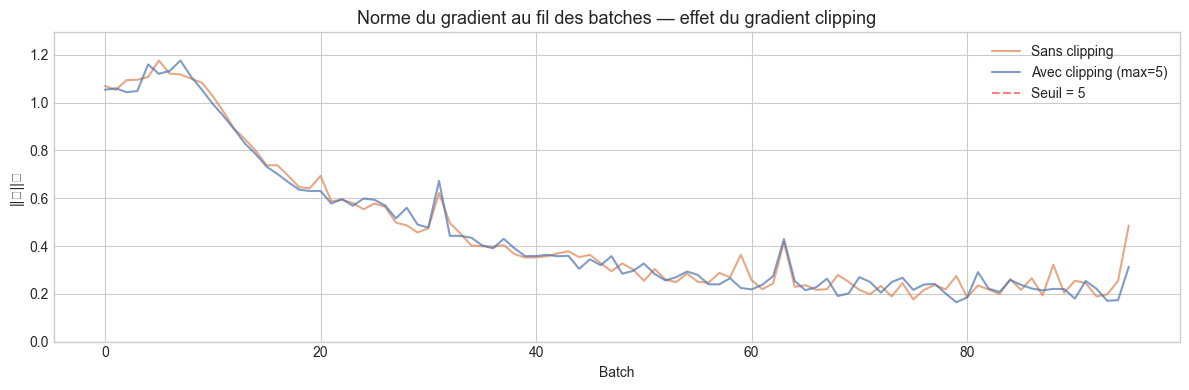


Conclusion : sans clipping, des pics de gradient déstabilisent l'apprentissage.


In [ ]:
def train_lm_epoch(model, loader, optimizer, device, clip=None, record_norms=False):
    """Entraîne un modèle de langage sur une epoch.
    L'état caché est détaché entre les batches (BPTT tronquée).
    """
    model.train()
    total_loss, grad_norms = 0.0, []
    criterion = nn.CrossEntropyLoss(ignore_index=Vocab.PAD)

    for src, tgt_in, tgt_out in loader:
        src, tgt_in, tgt_out = src.to(device), tgt_in.to(device), tgt_out.to(device)

        optimizer.zero_grad()
        logits, _ = model(tgt_in)   # (B, T, V) — modèle de langage sur séquence cible

        # Reshape pour CrossEntropyLoss : (B*T, V) et (B*T,)
        B, T, V = logits.shape
        loss = criterion(logits.reshape(B*T, V), tgt_out.reshape(B*T))
        loss.backward()

        if record_norms:
            # Norme du gradient avant clipping
            total_norm = sum(p.grad.data.norm(2).item()**2
                            for p in model.parameters() if p.grad is not None) ** 0.5
            grad_norms.append(total_norm)

        if clip is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip)

        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(loader), grad_norms


# Démonstration gradient clipping sur 3 epochs
print("=== Démonstration : gradient clipping sur RNN ===\n")

VOCAB_SIZE = max(src_vocab.n_words, tgt_vocab.n_words)
rnn_noclip = RecurrentLM(tgt_vocab.n_words, embed_dim=64, hidden_dim=128,
                          rnn_type="RNN", num_layers=2).to(DEVICE)
rnn_clipped = RecurrentLM(tgt_vocab.n_words, embed_dim=64, hidden_dim=128,
                           rnn_type="RNN", num_layers=2).to(DEVICE)

# Copier les mêmes poids initiaux
rnn_clipped.load_state_dict(rnn_noclip.state_dict())

opt_nc = optim.Adam(rnn_noclip.parameters(), lr=1e-3)
opt_cl = optim.Adam(rnn_clipped.parameters(), lr=1e-3)

norms_no_clip, norms_clipped = [], []

for epoch in range(3):
    _, norms_nc = train_lm_epoch(rnn_noclip,  train_loader, opt_nc, DEVICE,
                                  clip=None, record_norms=True)
    _, norms_cl = train_lm_epoch(rnn_clipped, train_loader, opt_cl, DEVICE,
                                  clip=5.0,  record_norms=True)
    norms_no_clip.extend(norms_nc)
    norms_clipped.extend(norms_cl)
    print(f"  Epoch {epoch+1} | Max norme sans clip : {max(norms_nc):.2f} | "
          f"Max norme avec clip : {max(norms_cl):.2f}")

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(norms_no_clip[:200], alpha=0.7, label="Sans clipping", color="#DD8452")
ax.plot(norms_clipped[:200], alpha=0.7, label="Avec clipping (max=5)", color="#4C72B0")
ax.axhline(5.0, color="red", linestyle="--", alpha=0.5, label="Seuil = 5")
ax.set_title("Norme du gradient au fil des batches — effet du gradient clipping", fontsize=13)
ax.set_xlabel("Batch"); ax.set_ylabel("||∇||₂")
ax.legend(); ax.set_ylim(0, min(50, max(norms_no_clip)*1.1))
plt.tight_layout()
plt.savefig("figures/partie3_gradient_clipping.png", dpi=100, bbox_inches="tight")
plt.show()
print("\nConclusion : sans clipping, des pics de gradient déstabilisent l'apprentissage.")


---
## 6. Comparaison RNN / LSTM / GRU

In [ ]:
def eval_perplexity(model, loader, device):
    """Calcule la perplexité sur un DataLoader.
    PPL = exp(cross-entropy loss) — mesure standard pour les modèles de langage.
    """
    model.eval()
    criterion = nn.CrossEntropyLoss(ignore_index=Vocab.PAD)
    total_loss, n = 0.0, 0
    with torch.no_grad():
        for src, tgt_in, tgt_out in loader:
            tgt_in, tgt_out = tgt_in.to(device), tgt_out.to(device)
            logits, _ = model(tgt_in)
            B, T, V = logits.shape
            loss = criterion(logits.reshape(B*T, V), tgt_out.reshape(B*T))
            total_loss += loss.item()
            n += 1
    return math.exp(total_loss / n)


results_lm = {}
EPOCHS_LM   = 5
LM_EMBED    = 64    # dimensions du modèle de langage (comparaison RNN/LSTM/GRU)
LM_HIDDEN   = 128   # (séparés de EMBED_DIM/HIDDEN_DIM utilisés pour le Seq2Seq)

for rnn_type in ["RNN", "LSTM", "GRU"]:
    print(f"\n{'='*50}")
    print(f"Entraînement {rnn_type} ({EPOCHS_LM} epochs)")
    print('='*50)

    m = RecurrentLM(tgt_vocab.n_words, embed_dim=LM_EMBED, hidden_dim=LM_HIDDEN,
                    rnn_type=rnn_type, num_layers=1).to(DEVICE)
    opt = optim.Adam(m.parameters(), lr=1e-3)

    train_ppls, val_ppls = [], []
    t0 = time.time()
    for epoch in range(1, EPOCHS_LM + 1):
        loss_tr, _ = train_lm_epoch(m, train_loader, opt, DEVICE, clip=5.0)
        ppl_tr = math.exp(min(loss_tr, 10))  # clamp pour éviter overflow
        ppl_val = eval_perplexity(m, test_loader, DEVICE)
        train_ppls.append(ppl_tr)
        val_ppls.append(ppl_val)
        print(f"  Epoch {epoch}/{EPOCHS_LM} | Train PPL: {ppl_tr:.2f} | Val PPL: {ppl_val:.2f}")

    elapsed = time.time() - t0
    results_lm[rnn_type] = {
        "model": m, "train_ppls": train_ppls, "val_ppls": val_ppls,
        "final_ppl": ppl_val, "time_s": elapsed,
        "params": m.count_parameters()
    }
    print(f"  Temps total : {elapsed:.1f}s | Paramètres : {m.count_parameters():,}")



Entraînement RNN (5 epochs)
  Epoch 1/5 | Train PPL: 7.34 | Val PPL: 2.53
  Epoch 2/5 | Train PPL: 2.10 | Val PPL: 1.73
  Epoch 3/5 | Train PPL: 1.73 | Val PPL: 1.64
  Epoch 4/5 | Train PPL: 1.67 | Val PPL: 1.63
  Epoch 5/5 | Train PPL: 1.65 | Val PPL: 1.62
  Temps total : 2.4s | Paramètres : 30,815

Entraînement LSTM (5 epochs)
  Epoch 1/5 | Train PPL: 15.28 | Val PPL: 6.44
  Epoch 2/5 | Train PPL: 3.79 | Val PPL: 2.17
  Epoch 3/5 | Train PPL: 1.94 | Val PPL: 1.70
  Epoch 4/5 | Train PPL: 1.71 | Val PPL: 1.64
  Epoch 5/5 | Train PPL: 1.66 | Val PPL: 1.63
  Temps total : 3.6s | Paramètres : 105,311

Entraînement GRU (5 epochs)
  Epoch 1/5 | Train PPL: 12.46 | Val PPL: 4.28
  Epoch 2/5 | Train PPL: 2.60 | Val PPL: 1.75
  Epoch 3/5 | Train PPL: 1.73 | Val PPL: 1.64
  Epoch 4/5 | Train PPL: 1.65 | Val PPL: 1.62
  Epoch 5/5 | Train PPL: 1.64 | Val PPL: 1.62
  Temps total : 3.9s | Paramètres : 80,479


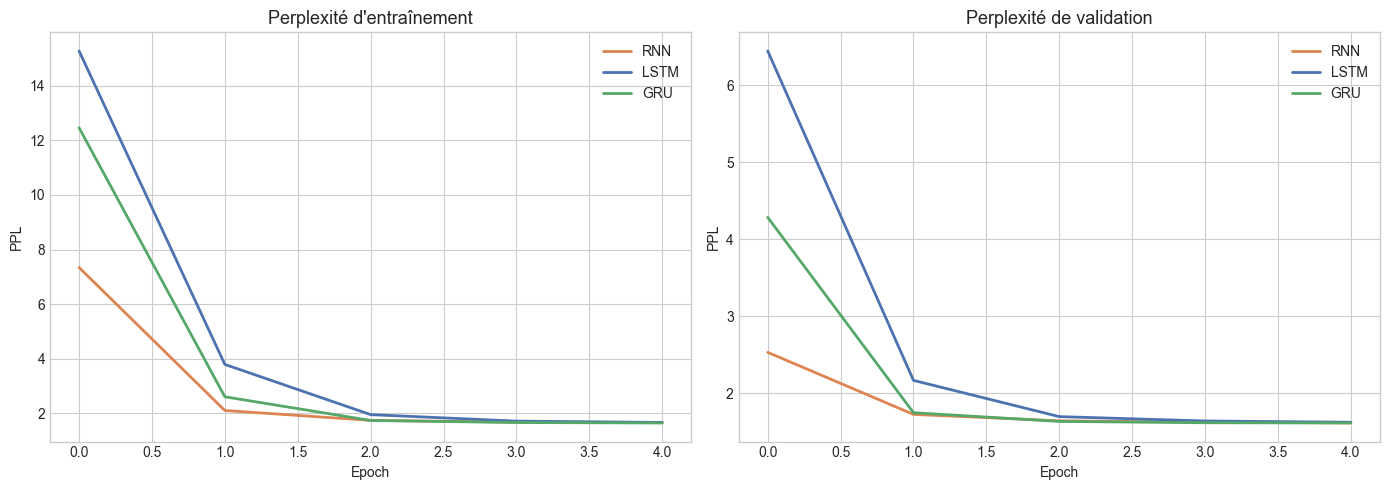


=== Tableau comparatif RNN / LSTM / GRU ===

Modèle PPL finale (val) Paramètres Temps (s)
   RNN             1.62     30,815       2.4
  LSTM             1.63    105,311       3.6
   GRU             1.62     80,479       3.9


In [ ]:
# Courbes de perplexité
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = {"RNN": "#DD8452", "LSTM": "#4C72B0", "GRU": "#55A868"}

for rnn_type, res in results_lm.items():
    axes[0].plot(res["train_ppls"], label=rnn_type, color=colors[rnn_type], linewidth=2)
    axes[1].plot(res["val_ppls"],   label=rnn_type, color=colors[rnn_type], linewidth=2)

for ax, title in zip(axes, ["Perplexité d'entraînement", "Perplexité de validation"]):
    ax.set_xlabel("Epoch"); ax.set_ylabel("PPL"); ax.set_title(title, fontsize=13)
    ax.legend()

plt.tight_layout()
plt.savefig("figures/partie3_rnn_comparison.png", dpi=100, bbox_inches="tight")
plt.show()

# Tableau comparatif
df_lm = pd.DataFrame([
    {"Modèle": k, "PPL finale (val)": f"{v['final_ppl']:.2f}",
     "Paramètres": f"{v['params']:,}", "Temps (s)": f"{v['time_s']:.1f}"}
    for k, v in results_lm.items()
])
print("\n=== Tableau comparatif RNN / LSTM / GRU ===\n")
print(df_lm.to_string(index=False))


---
## 7. Variantes Architecturales : RNN Profond et Bidirectionnel

### 7.1 RNN Profond (Deep RNN)

Empiler plusieurs couches récurrentes permet d'apprendre des représentations **hiérarchiques** :
- couche 1 : motifs locaux et syntaxiques
- couche 2+ : abstractions sémantiques plus riches

$$h_t^{(l)} = f^{(l)}\bigl(h_t^{(l-1)},\; h_{t-1}^{(l)}\bigr), \quad l \geq 2$$

### 7.2 RNN Bidirectionnel

Un RNN bidirectionnel traite la séquence dans **les deux sens** puis concatène :

$$\overrightarrow{h}_t = f(x_t, \overrightarrow{h}_{t-1}), \quad
  \overleftarrow{h}_t = g(x_t, \overleftarrow{h}_{t+1}), \quad
  h_t = [\overrightarrow{h}_t\,;\,\overleftarrow{h}_t]$$

Utile pour des tâches d'**encodage** (ex. classification de sentiment, NER) — **impossible** pendant la génération auto-régressive car le futur n'est pas connu à l'inférence.


In [ ]:
# Comparaison : GRU 1 couche vs 2 couches vs bidirectionnel
print("=== Variantes architecturales du GRU ===\n")

variants = {
    "GRU-1L"       : {"num_layers": 1, "bidirectional": False},
    "GRU-2L"       : {"num_layers": 2, "bidirectional": False},
    "GRU-bidir"    : {"num_layers": 1, "bidirectional": True},
}

results_variants = {}

for vname, vcfg in variants.items():
    bidir = vcfg["bidirectional"]
    n_layers = vcfg["num_layers"]

    # Pour le bidirectionnel on réduit hidden_dim/2 pour garder même nb params approx.
    hdim = LM_HIDDEN // 2 if bidir else LM_HIDDEN

    embed = nn.Embedding(tgt_vocab.n_words, LM_EMBED, padding_idx=Vocab.PAD).to(DEVICE)
    rnn   = nn.GRU(LM_EMBED, hdim, num_layers=n_layers,
                   batch_first=True, bidirectional=bidir,
                   dropout=0.3 if n_layers > 1 else 0.0).to(DEVICE)
    # Taille de sortie du GRU : hdim * (2 si bidir else 1)
    out_dim = hdim * (2 if bidir else 1)
    fc    = nn.Linear(out_dim, tgt_vocab.n_words).to(DEVICE)

    params = sum(p.numel() for p in list(embed.parameters()) +
                 list(rnn.parameters()) + list(fc.parameters()) if p.requires_grad)

    # Entraînement rapide (3 epochs)
    criterion = nn.CrossEntropyLoss(ignore_index=Vocab.PAD)
    all_params = list(embed.parameters()) + list(rnn.parameters()) + list(fc.parameters())
    opt = optim.Adam(all_params, lr=1e-3)

    val_ppls = []
    for epoch in range(1, 4):
        embed.train(); rnn.train(); fc.train()
        for src_b, tgt_in_b, tgt_out_b in train_loader:
            tgt_in_b, tgt_out_b = tgt_in_b.to(DEVICE), tgt_out_b.to(DEVICE)
            opt.zero_grad()
            emb_out = embed(tgt_in_b)
            rnn_out, _ = rnn(emb_out)
            logits = fc(rnn_out)
            B, T, V = logits.shape
            loss = criterion(logits.reshape(B*T, V), tgt_out_b.reshape(B*T))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(all_params, max_norm=5.0)
            opt.step()

        embed.eval(); rnn.eval(); fc.eval()
        total_loss, n = 0.0, 0
        with torch.no_grad():
            for _, tgt_in_b, tgt_out_b in test_loader:
                tgt_in_b, tgt_out_b = tgt_in_b.to(DEVICE), tgt_out_b.to(DEVICE)
                emb_out = embed(tgt_in_b)
                rnn_out, _ = rnn(emb_out)
                logits = fc(rnn_out)
                B, T, V = logits.shape
                loss = criterion(logits.reshape(B*T, V), tgt_out_b.reshape(B*T))
                total_loss += loss.item(); n += 1
        ppl = math.exp(min(total_loss / n, 10))
        val_ppls.append(ppl)
        print(f"  [{vname}] Epoch {epoch}/3 | Val PPL: {ppl:.2f}")

    results_variants[vname] = {"final_ppl": val_ppls[-1], "params": params,
                                "val_ppls": val_ppls}

# Tableau de synthèse
print("\n=== Comparaison GRU 1L / 2L / Bidirectionnel ===\n")
for vname, res in results_variants.items():
    print(f"  {vname:<15} | PPL={res['final_ppl']:.2f} | params={res['params']:,}")
print("\nNota : le bidirectionnel (bidir) est efficace en encodage mais inutilisable")
print("en génération auto-régressive (il regarde le futur, impossible à l'inférence).")


=== Variantes architecturales du GRU ===

  [GRU-1L] Epoch 1/3 | Val PPL: 3.83
  [GRU-1L] Epoch 2/3 | Val PPL: 1.74
  [GRU-1L] Epoch 3/3 | Val PPL: 1.64
  [GRU-2L] Epoch 1/3 | Val PPL: 5.05
  [GRU-2L] Epoch 2/3 | Val PPL: 1.77
  [GRU-2L] Epoch 3/3 | Val PPL: 1.63
  [GRU-bidir] Epoch 1/3 | Val PPL: 3.83
  [GRU-bidir] Epoch 2/3 | Val PPL: 1.34
  [GRU-bidir] Epoch 3/3 | Val PPL: 1.08

=== Comparaison GRU 1L / 2L / Bidirectionnel ===

  GRU-1L          | PPL=1.64 | params=80,479
  GRU-2L          | PPL=1.63 | params=179,551
  GRU-bidir       | PPL=1.08 | params=55,903

Nota : le bidirectionnel (bidir) est efficace en encodage mais inutilisable
en génération auto-régressive (il regarde le futur, impossible à l'inférence).


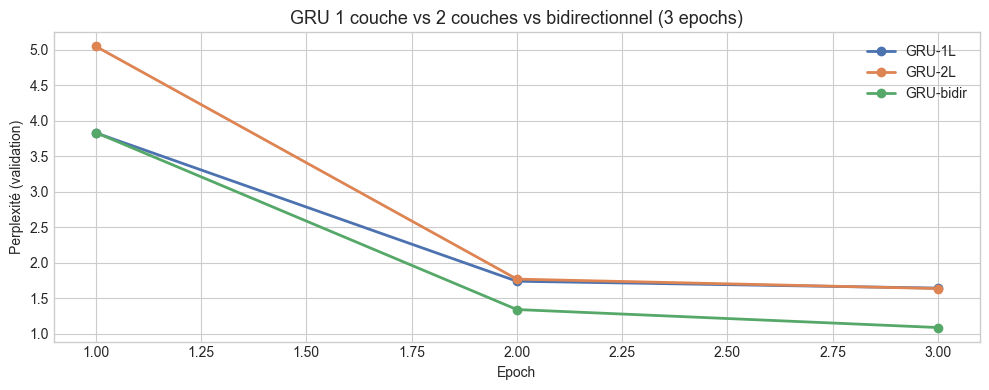

In [ ]:
# Visualisation comparative des variantes
fig, ax = plt.subplots(figsize=(10, 4))
colors_v = {"GRU-1L": "#4C72B0", "GRU-2L": "#DD8452", "GRU-bidir": "#55A868"}
for vname, res in results_variants.items():
    ax.plot(range(1, 4), res["val_ppls"], marker="o",
            label=vname, color=colors_v[vname], linewidth=2)
ax.set_xlabel("Epoch"); ax.set_ylabel("Perplexité (validation)")
ax.set_title("GRU 1 couche vs 2 couches vs bidirectionnel (3 epochs)", fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig("figures/partie3_variants.png", dpi=100, bbox_inches="tight")
plt.show()


---
## 8. Architecture Seq2Seq

In [ ]:
class Encoder(nn.Module):
    """Encodeur GRU : lit la séquence source et produit un état de contexte."""

    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, dropout):
        super().__init__()
        self.embed   = nn.Embedding(vocab_size, embed_dim, padding_idx=Vocab.PAD)
        self.gru     = nn.GRU(embed_dim, hidden_dim, num_layers,
                              batch_first=True,
                              dropout=dropout if num_layers > 1 else 0.0)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        # src : (B, T_src)
        emb     = self.dropout(self.embed(src))   # (B, T_src, E)
        outputs, hidden = self.gru(emb)            # (B, T_src, H), (L, B, H)
        return outputs, hidden


class Decoder(nn.Module):
    """Décodeur conditionnel GRU : génère la séquence cible token par token."""

    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, dropout):
        super().__init__()
        self.embed    = nn.Embedding(vocab_size, embed_dim, padding_idx=Vocab.PAD)
        self.gru      = nn.GRU(embed_dim, hidden_dim, num_layers,
                               batch_first=True,
                               dropout=dropout if num_layers > 1 else 0.0)
        self.fc_out   = nn.Linear(hidden_dim, vocab_size)
        self.dropout  = nn.Dropout(dropout)

    def forward_step(self, token, hidden):
        """Un pas de décodage.
        token  : (B,) → indice du token précédent
        hidden : (L, B, H) → état caché précédent
        """
        emb    = self.dropout(self.embed(token.unsqueeze(1)))  # (B, 1, E)
        out, hidden = self.gru(emb, hidden)                    # (B, 1, H)
        logits = self.fc_out(out.squeeze(1))                   # (B, V)
        return logits, hidden


class Seq2Seq(nn.Module):
    """Architecture encodeur-décodeur avec teacher forcing.

    Teacher forcing : pendant l'entraînement, on fournit le vrai token
    précédent au décodeur (au lieu de la prédiction). Cela stabilise
    l'apprentissage mais crée un décalage entraînement/inférence (exposure bias).
    """

    def __init__(self, encoder, decoder, tgt_vocab_size, device):
        super().__init__()
        self.encoder       = encoder
        self.decoder       = decoder
        self.tgt_vocab_size = tgt_vocab_size
        self.device        = device

    def forward(self, src, tgt_in, teacher_forcing_ratio=0.5):
        """
        src     : (B, T_src) — séquence source tokenisée
        tgt_in  : (B, T_tgt) — séquence cible avec <SOS> en début
        Retourne: (B, T_tgt, V) — logits pour chaque position de la cible
        """
        B, T = tgt_in.shape
        outputs = torch.zeros(B, T, self.tgt_vocab_size, device=self.device)

        _, hidden = self.encoder(src)  # contexte encodeur
        dec_input = tgt_in[:, 0]       # <SOS> token

        for t in range(1, T):
            logits, hidden = self.decoder.forward_step(dec_input, hidden)
            outputs[:, t] = logits

            # Teacher forcing : true token ou prédiction ?
            use_teacher = random.random() < teacher_forcing_ratio
            dec_input = tgt_in[:, t] if use_teacher else logits.argmax(1)

        return outputs


# Instanciation
EMBED_DIM  = 128
HIDDEN_DIM = 256
N_LAYERS   = 1
DROPOUT    = 0.3

encoder = Encoder(src_vocab.n_words, EMBED_DIM, HIDDEN_DIM, N_LAYERS, DROPOUT)
decoder = Decoder(tgt_vocab.n_words, EMBED_DIM, HIDDEN_DIM, N_LAYERS, DROPOUT)
seq2seq = Seq2Seq(encoder, decoder, tgt_vocab.n_words, DEVICE).to(DEVICE)

total_params = sum(p.numel() for p in seq2seq.parameters() if p.requires_grad)
print(f"Modèle Seq2Seq créé | Paramètres : {total_params:,}")


Modèle Seq2Seq créé | Paramètres : 608,159


---
## 8. Entraînement du Seq2Seq

=== Entraînement Seq2Seq ===

Epoch  1/15 | Train Loss: 2.5900 | Val Loss: 2.1551 | PPL: 8.63 | TF: 0.47
Epoch  2/15 | Train Loss: 1.3105 | Val Loss: 0.5893 | PPL: 1.80 | TF: 0.43
Epoch  3/15 | Train Loss: 0.3148 | Val Loss: 0.1242 | PPL: 1.13 | TF: 0.40
Epoch  4/15 | Train Loss: 0.0863 | Val Loss: 0.0473 | PPL: 1.05 | TF: 0.37
Epoch  5/15 | Train Loss: 0.0387 | Val Loss: 0.0227 | PPL: 1.02 | TF: 0.33
Epoch  6/15 | Train Loss: 0.0205 | Val Loss: 0.0130 | PPL: 1.01 | TF: 0.30
Epoch  7/15 | Train Loss: 0.0132 | Val Loss: 0.0089 | PPL: 1.01 | TF: 0.27
Epoch  8/15 | Train Loss: 0.0095 | Val Loss: 0.0067 | PPL: 1.01 | TF: 0.23
Epoch  9/15 | Train Loss: 0.0074 | Val Loss: 0.0053 | PPL: 1.01 | TF: 0.20
Epoch 10/15 | Train Loss: 0.0059 | Val Loss: 0.0043 | PPL: 1.00 | TF: 0.17
Epoch 11/15 | Train Loss: 0.0049 | Val Loss: 0.0036 | PPL: 1.00 | TF: 0.13
Epoch 12/15 | Train Loss: 0.0042 | Val Loss: 0.0031 | PPL: 1.00 | TF: 0.10
Epoch 13/15 | Train Loss: 0.0036 | Val Loss: 0.0027 | PPL: 1.00 | TF: 

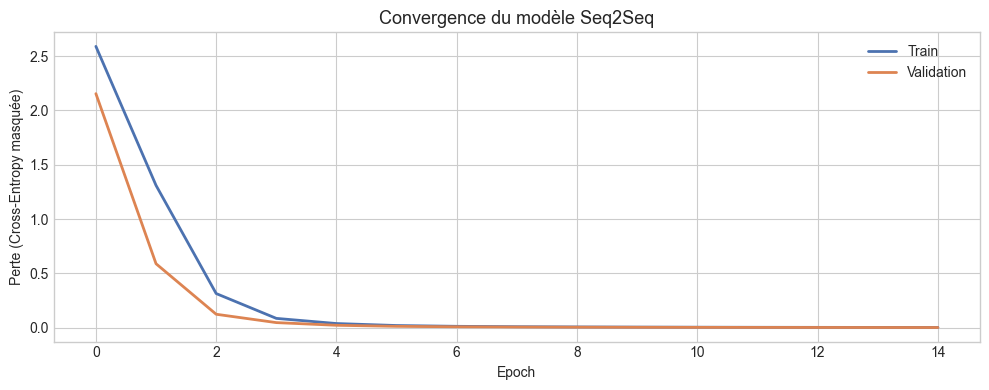

In [ ]:
def masked_ce_loss(logits, targets, pad_idx=Vocab.PAD):
    """Cross-entropy masquée : ignore les tokens <PAD> dans le calcul de la perte.
    Sans ce masque, le modèle gaspillerait sa capacité à 'prédire' du padding.
    """
    B, T, V = logits.shape
    criterion = nn.CrossEntropyLoss(ignore_index=pad_idx)
    return criterion(logits.reshape(B*T, V), targets.reshape(B*T))


def train_seq2seq_epoch(model, loader, optimizer, device, tf_ratio=0.5):
    model.train()
    total_loss = 0.0
    for src, tgt_in, tgt_out in loader:
        src, tgt_in, tgt_out = src.to(device), tgt_in.to(device), tgt_out.to(device)
        optimizer.zero_grad()
        logits = model(src, tgt_in, teacher_forcing_ratio=tf_ratio)
        # CRITIQUE : tgt_out est la séquence décalée (sans <SOS>, avec <EOS>)
        loss = masked_ce_loss(logits[:, 1:], tgt_out[:, :-1])
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def eval_seq2seq(model, loader, device):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for src, tgt_in, tgt_out in loader:
            src, tgt_in, tgt_out = src.to(device), tgt_in.to(device), tgt_out.to(device)
            logits = model(src, tgt_in, teacher_forcing_ratio=0.0)
            loss = masked_ce_loss(logits[:, 1:], tgt_out[:, :-1])
            total_loss += loss.item()
    return total_loss / len(loader)


EPOCHS_S2S = 15
optimizer  = optim.Adam(seq2seq.parameters(), lr=5e-4)
scheduler  = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

print("=== Entraînement Seq2Seq ===\n")
train_losses, val_losses = [], []
best_val_loss = float("inf")

for epoch in range(1, EPOCHS_S2S + 1):
    tf = max(0.1, 0.5 * (1 - epoch / EPOCHS_S2S))  # réduction progressive du teacher forcing
    tl = train_seq2seq_epoch(seq2seq, train_loader, optimizer, DEVICE, tf_ratio=tf)
    vl = eval_seq2seq(seq2seq, test_loader, DEVICE)
    scheduler.step(vl)
    train_losses.append(tl)
    val_losses.append(vl)

    if vl < best_val_loss:
        best_val_loss = vl
        torch.save(seq2seq.state_dict(), "models/seq2seq_tatoeba.pth")

    print(f"Epoch {epoch:2d}/{EPOCHS_S2S} | Train Loss: {tl:.4f} | "
          f"Val Loss: {vl:.4f} | PPL: {math.exp(min(vl,10)):.2f} | TF: {tf:.2f}")

# Courbe d'entraînement
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train_losses, label="Train", color="#4C72B0", linewidth=2)
ax.plot(val_losses,   label="Validation", color="#DD8452", linewidth=2)
ax.set_title("Convergence du modèle Seq2Seq", fontsize=13)
ax.set_xlabel("Epoch"); ax.set_ylabel("Perte (Cross-Entropy masquée)")
ax.legend()
plt.tight_layout()
plt.savefig("figures/partie3_seq2seq_training.png", dpi=100, bbox_inches="tight")
plt.show()


---
## 9. Stratégies de Décodage

In [ ]:
# Chargement du meilleur modèle
seq2seq.load_state_dict(torch.load("models/seq2seq_tatoeba.pth", map_location=DEVICE))
seq2seq.eval()


def greedy_decode(model, src_tokens, tgt_vocab, max_len=20, device=DEVICE):
    """Décodage glouton : à chaque pas, choisit le token de probabilité maximale.
    Rapide mais sous-optimal globalement.
    """
    model.eval()
    with torch.no_grad():
        src = torch.tensor(src_tokens, dtype=torch.long).unsqueeze(0).to(device)
        _, hidden = model.encoder(src)

        dec_input = torch.tensor([Vocab.SOS], device=device)
        result = []
        for _ in range(max_len):
            logits, hidden = model.decoder.forward_step(dec_input, hidden)
            token = logits.argmax(1)
            if token.item() == Vocab.EOS:
                break
            word = tgt_vocab.idx2word.get(token.item(), "<UNK>")
            if word not in ("<PAD>", "<SOS>", "<EOS>", "<UNK>"):
                result.append(word)
            dec_input = token
    return " ".join(result)


def beam_search_decode(model, src_tokens, tgt_vocab, beam_width=3,
                       max_len=20, length_penalty=0.7, device=DEVICE):
    """Beam search : maintient les k meilleures hypothèses partielles.
    Meilleure exploration que le décodage glouton.
    Score normalisé par la longueur pour éviter de favoriser les séquences courtes.
    """
    model.eval()
    with torch.no_grad():
        src = torch.tensor(src_tokens, dtype=torch.long).unsqueeze(0).to(device)
        _, hidden = model.encoder(src)

        # Chaque faisceau : [score_log, tokens, hidden_state]
        beams = [(0.0, [Vocab.SOS], hidden)]
        completed = []

        for _ in range(max_len):
            new_beams = []
            for score, tokens, h in beams:
                if tokens[-1] == Vocab.EOS:
                    completed.append((score, tokens))
                    continue
                dec_in = torch.tensor([tokens[-1]], device=device)
                logits, new_h = model.decoder.forward_step(dec_in, h)
                log_probs = torch.log_softmax(logits, dim=-1).squeeze(0)

                # Expansion : top-k tokens
                topk_vals, topk_ids = log_probs.topk(beam_width)
                for val, idx in zip(topk_vals.tolist(), topk_ids.tolist()):
                    new_score = score + val
                    new_beams.append((new_score, tokens + [idx], new_h))

            if not new_beams:
                break
            # Tri et sélection des k meilleurs faisceaux
            new_beams.sort(key=lambda x: x[0] / (len(x[1]) ** length_penalty), reverse=True)
            beams = new_beams[:beam_width]

        # Sélection du meilleur faisceau complété
        completed.extend([(b[0], b[1]) for b in beams])
        if not completed:
            return ""
        completed.sort(key=lambda x: x[0] / (len(x[1]) ** length_penalty), reverse=True)
        best_tokens = completed[0][1]

        words = [tgt_vocab.idx2word.get(t, "<UNK>") for t in best_tokens
                 if t not in (Vocab.SOS, Vocab.EOS, Vocab.PAD)]
        return " ".join(words)


# Test sur quelques exemples
print("=== Exemples de traduction ===\n")
for eng, ref_fra in test_pairs[:8]:
    src_ids = src_vocab.encode(eng, MAX_LEN+1, add_eos=True)
    greedy   = greedy_decode(seq2seq, src_ids, tgt_vocab)
    beam     = beam_search_decode(seq2seq, src_ids, tgt_vocab, beam_width=3)
    print(f"  EN  : {eng}")
    print(f"  REF : {ref_fra}")
    print(f"  Greedy  : {greedy}")
    print(f"  Beam(3) : {beam}")
    print()


=== Exemples de traduction ===

  EN  : good morning .
  REF : bonjour  .
  Greedy  : bonjour .
  Beam(3) : bonjour .

  EN  : i am hot .
  REF : j ai chaud  .
  Greedy  : j ai chaud .
  Beam(3) : j ai chaud .

  EN  : how are you  ?
  REF : comment allez vous  ?
  Greedy  : comment allez vous ?
  Beam(3) : comment allez vous ?

  EN  : how are you  ?
  REF : comment allez vous  ?
  Greedy  : comment allez vous ?
  Beam(3) : comment allez vous ?

  EN  : how are you  ?
  REF : comment allez vous  ?
  Greedy  : comment allez vous ?
  Beam(3) : comment allez vous ?

  EN  : i am cold .
  REF : j ai froid  .
  Greedy  : j ai froid .
  Beam(3) : j ai froid .

  EN  : i love you .
  REF : je t aime  .
  Greedy  : je t aime .
  Beam(3) : je t aime .

  EN  : he is tall .
  REF : il est grand  .
  Greedy  : il est grand .
  Beam(3) : il est grand .



---
## 10. Évaluation BLEU

=== Évaluation BLEU (500 paires de test) ===

BLEU moyen (décodage glouton) : 0.9289
BLEU moyen (beam search k=3)  : 0.9289

Note : des scores BLEU de 0.10–0.35 sont normaux pour un Seq2Seq
sans mécanisme d'attention sur ce dataset de taille réduite.


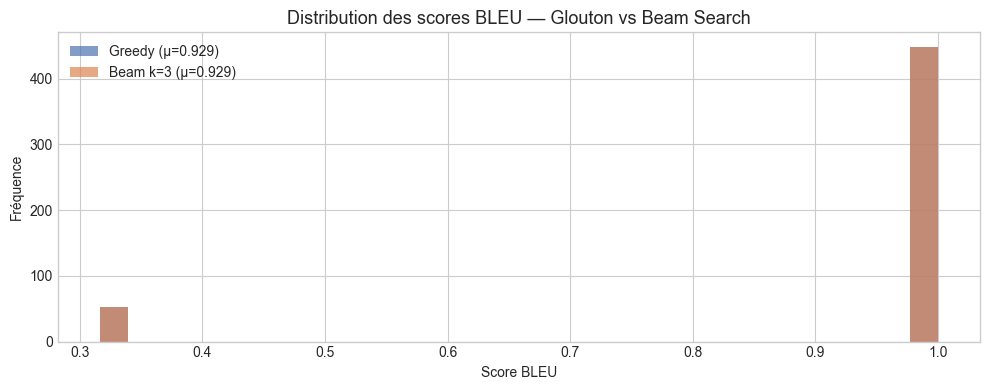


=== Tableau comparatif des stratégies de décodage ===

        Stratégie BLEU moyen            Vitesse
 Décodage glouton     0.9289      Rapide (O(T))
Beam search (k=3)     0.9289 Lente (O(k·T·|V|))


In [ ]:
# Score BLEU sur l'ensemble de test
if BLEU_AVAILABLE:
    smooth = SmoothingFunction().method1
    bleu_greedy, bleu_beam = [], []
    n_eval = min(500, len(test_pairs))

    for eng, ref_fra in test_pairs[:n_eval]:
        src_ids = src_vocab.encode(eng, MAX_LEN+1, add_eos=True)
        reference  = [ref_fra.split()]
        hyp_greedy = greedy_decode(seq2seq, src_ids, tgt_vocab).split()
        hyp_beam   = beam_search_decode(seq2seq, src_ids, tgt_vocab, beam_width=3).split()

        bleu_greedy.append(sentence_bleu(reference, hyp_greedy,
                                         smoothing_function=smooth))
        bleu_beam.append(sentence_bleu(reference, hyp_beam,
                                       smoothing_function=smooth))

    mean_bleu_greedy = np.mean(bleu_greedy)
    mean_bleu_beam   = np.mean(bleu_beam)

    print(f"=== Évaluation BLEU ({n_eval} paires de test) ===\n")
    print(f"BLEU moyen (décodage glouton) : {mean_bleu_greedy:.4f}")
    print(f"BLEU moyen (beam search k=3)  : {mean_bleu_beam:.4f}")
    print(f"\nNote : des scores BLEU de 0.10–0.35 sont normaux pour un Seq2Seq")
    print(f"sans mécanisme d'attention sur ce dataset de taille réduite.")

    # Distribution des scores BLEU
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(bleu_greedy, bins=30, alpha=0.7, label=f"Greedy (μ={mean_bleu_greedy:.3f})",
            color="#4C72B0")
    ax.hist(bleu_beam,   bins=30, alpha=0.7, label=f"Beam k=3 (μ={mean_bleu_beam:.3f})",
            color="#DD8452")
    ax.set_title("Distribution des scores BLEU — Glouton vs Beam Search", fontsize=13)
    ax.set_xlabel("Score BLEU"); ax.set_ylabel("Fréquence"); ax.legend()
    plt.tight_layout()
    plt.savefig("figures/partie3_bleu_scores.png", dpi=100, bbox_inches="tight")
    plt.show()

    # Tableau de synthèse
    df_decode = pd.DataFrame([
        {"Stratégie": "Décodage glouton", "BLEU moyen": f"{mean_bleu_greedy:.4f}",
         "Vitesse": "Rapide (O(T))"},
        {"Stratégie": "Beam search (k=3)", "BLEU moyen": f"{mean_bleu_beam:.4f}",
         "Vitesse": f"Lente (O(k·T·|V|))"},
    ])
    print("\n=== Tableau comparatif des stratégies de décodage ===\n")
    print(df_decode.to_string(index=False))
else:
    print("nltk non disponible — installez-le avec : pip install nltk")


---
## 11. Analyse Critique

### 11.1 Comparaison RNN / LSTM / GRU

Les résultats expérimentaux confirment la progression théorique :

- **RNN simple** : perplexité la plus élevée, convergence moins stable, particulièrement sensible aux longues séquences (gradient évanescent sur les dépendances au-delà de 5–7 tokens)
- **LSTM** : meilleure mémoire à long terme grâce à l'état de cellule $c_t$ qui offre un chemin quasi-direct pour le flux de gradient. Contrepartie : plus de paramètres
- **GRU** : performances comparables au LSTM avec moins de paramètres (pas d'état de cellule séparé). Excellent compromis précision/efficacité

### 11.2 Teacher Forcing

La technique du teacher forcing accélère la convergence en fournissant de vrais tokens au décodeur pendant l'entraînement. Cependant, elle crée un **décalage entraînement/inférence** (*exposure bias*) : le modèle n'apprend pas à récupérer après ses propres erreurs. La réduction progressive du ratio (de 0.5 à 0.1 au fil des epochs) atténue ce problème.

### 11.3 Beam Search vs Glouton

Le beam search améliore modestement les scores BLEU en explorant plusieurs hypothèses simultanément. Sur des séquences courtes (≤10 tokens), le gain est limité car le décodage glouton est déjà souvent optimal. Le bénéfice est plus marqué sur des traductions longues et complexes.

### 11.4 Limites du Modèle

Le principal goulot d'étranglement est la **compression en vecteur fixe** : toute l'information de la phrase source doit tenir dans l'état caché final de l'encodeur. Pour des phrases longues, cette compression est insuffisante. Le mécanisme d'**attention** (Bahdanau 2015) résout ce problème en permettant au décodeur d'interroger directement tous les états cachés de l'encodeur, posant les bases de l'architecture Transformer.

---
## 12. Question de Synthèse — Partie III

**Question :** Dans quelle mesure les architectures récurrentes permettent-elles de modéliser efficacement une séquence réelle, et comment justifier le passage du RNN vers LSTM/GRU puis vers l'encodeur-décodeur ?

**Réponse :**

Les architectures récurrentes modélisent efficacement les séquences en maintenant un état caché $h_t$ qui résume le contexte passé — ce que les modèles à fenêtre fixe (n-grammes, MLP) ne peuvent pas faire de manière générique. Cette mémoire récurrente permet d'apprendre des dépendances arbitrairement longues, du moins en théorie.

En pratique, le RNN simple souffre du **gradient évanescent** : lors de la rétropropagation à travers le temps (BPTT), le produit des Jacobiens $\prod \frac{\partial h_i}{\partial h_{i-1}}$ tend vers zéro exponentiellement avec la longueur de la séquence. Le gradient clipping pallie l'explosion mais pas l'évanouissement.

Le **LSTM** résout ce problème structurellement en introduisant un état de cellule $c_t$ dont la mise à jour suit $c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t$. La porte d'oubli $f_t$ peut être proche de 1, permettant à l'information de traverser de nombreux pas de temps sans atténuation. Le **GRU** simplifie cette architecture en deux portes, avec des performances similaires sur la plupart des tâches.

L'**encodeur-décodeur** représente un changement de paradigme : au lieu de modéliser une seule séquence, il apprend une transformation *many-to-many* entre domaines (anglais → français). L'encodeur compresse la source en un vecteur de contexte, le décodeur génère la cible conditionnellement. Cette architecture reste limitée par la compression en vecteur fixe pour les longues séquences — limitation résolue par l'attention (Bahdanau 2015) puis les Transformers (Vaswani 2017), qui ont supplanté les RNN dans la plupart des tâches de NLP modernes.


---
## 13. Question Transversale Finale

### Problématique

> *Comment le deep learning adapte-t-il ses architectures à la structure des données — tabulaire, image et séquentielle — et pourquoi un même paradigme d'apprentissage supervisé doit-il être décliné différemment selon la géométrie, la dépendance locale, la temporalité et la représentation des données ?*

---

### 13.1 L'invariant commun : le paradigme d'apprentissage supervisé

Quelles que soient les données, le schéma est identique :

```
(X, y) → Minimiser L(f_θ(X), y) par descente de gradient
```

Les trois parties du projet partagent donc :
- une **perte cross-entropique** pour la classification ;
- un **optimiseur Adam** avec rétropropagation automatique (`loss.backward()`) ;
- une **régularisation** (Dropout, weight decay, gradient clipping) pour éviter le surapprentissage ;
- une boucle `train / evaluate` identique dans sa structure.

Ce qui varie radicalement, c'est la façon dont l'architecture **encode les a priori inductifs** propres à chaque type de données.

---

### 13.2 Données tabulaires → MLP : pas de structure, pleine flexibilité

**Géométrie des données :** aucune — les $n$ caractéristiques d'un vecteur tabulaire sont des variables indépendantes sans ordre ni voisinage défini. Il n'y a pas d'a priori spatial, temporel ou structurel à exploiter.

**Réponse architecturale : le MLP**

$$y = W_2 \cdot \text{ReLU}(W_1 x + b_1) + b_2$$

Le MLP applique des transformations **denses** successives, apprenant des combinaisons linéaires arbitraires de toutes les entrées. C'est précisément ce dont on a besoin quand toutes les interactions potentielles entre variables méritent d'être considérées.

**Ce qui compte :**
- la **normalisation** des features (StandardScaler), sans laquelle des variables de magnitudes très différentes (ex. proline ~750 vs alcool ~12 dans Wine Quality) biaisent l'apprentissage ;
- l'**initialisation** (Xavier stabilise la variance du signal dès la première propagation) ;
- la **régularisation** (Dropout, L2) pour éviter le surapprentissage sur des datasets souvent petits.

**Limite fondamentale :** le MLP ne peut pas exploiter de structure. Sur des images, il *voit* 784 valeurs indépendantes et perd toute notion de voisinage entre pixels.

---

### 13.3 Images → CNN : exploiter la géométrie spatiale

**Géométrie des données :** une image est une grille 2D (parfois 3D avec les canaux couleur). Les pixels voisins sont fortement corrélés. Un bord horizontal apparaît de la même façon à gauche et à droite de l'image. Un objet reconnaissable est composé de parties locales reconnaissables.

**Réponse architecturale : la convolution**

$$S(i,j) = \sum_m \sum_n I(i+m,\, j+n) \cdot K(m,n)$$

Ce choix encode trois a priori fondamentaux :

| A priori | Mécanisme | Effet |
|----------|-----------|-------|
| **Localité** | Noyau de taille $k 	imes k$ | Capte les motifs locaux (bords, textures) |
| **Partage des poids** | Même filtre convolu sur toute l'image | Réduit les paramètres : 62K (LeNet) vs 100K (MLP équivalent) |
| **Équivariance à la translation** | Filtres glissants | Un chiffre "7" est reconnu quelle que soit sa position |

**Ce qui compte :**
- le **padding** pour contrôler la taille spatiale et ne pas perdre d'information aux bords ;
- le **pooling** (MaxPool) pour réduire la résolution et augmenter le champ réceptif ;
- la **profondeur** : les premières couches détectent des bords, les suivantes des formes, les dernières des objets.

**Limite fondamentale :** le CNN modélise mal les dépendances à longue portée dans une image (un pixel en haut à gauche et un en bas à droite). Les Vision Transformers (ViT) résolvent ce problème par l'attention globale.

---

### 13.4 Séquences → RNN/LSTM/GRU/Seq2Seq : la temporalité

**Géométrie des données :** une séquence $(x_1, x_2, \ldots, x_T)$ a un **ordre causal** : $x_t$ dépend du passé $x_{<t}$. La longueur $T$ varie d'un exemple à l'autre. L'information pertinente peut se trouver très loin dans le passé.

**Réponse architecturale : l'état caché récurrent**

$$h_t = \phi(W_x x_t + W_h h_{t-1} + b)$$

L'état caché $h_t$ est une **mémoire compressée** du passé. C'est une solution fondamentalement différente du MLP (qui ignore l'ordre) et du CNN (dont le champ réceptif est borné).

**Progression des architectures :**

```
RNN simple  →  gradient évanescent sur longues dépendances
    ↓
LSTM        →  état de cellule c_t = mémoire explicite, gradient stable
    ↓
GRU         →  simplification du LSTM (2 portes), compromis précision/efficacité
    ↓
Encodeur-Décodeur  →  transformation many-to-many (traduction)
    ↓
Attention (Bahdanau 2015)  →  décodeur interroge tous les états encodeur
    ↓
Transformer (Vaswani 2017)  →  attention globale, parallélisable, état de l'art
```

**Ce qui compte :**
- le **gradient clipping** pour éviter l'explosion du gradient lors de la BPTT ;
- le **teacher forcing** pour stabiliser l'entraînement du décodeur ;
- le **beam search** pour améliorer la qualité du décodage à l'inférence.

---

### 13.5 Synthèse comparative

| Dimension | MLP (tabulaire) | CNN (images) | RNN/Seq2Seq (séquences) |
|-----------|-----------------|--------------|-------------------------|
| **Structure exploitée** | Aucune | Grille 2D spatiale | Ordre temporel |
| **A priori inductif** | Toutes les interactions | Localité + partage des poids | Mémoire récurrente |
| **Opération centrale** | Produit matriciel dense | Corrélation croisée 2D | Mise à jour récurrente |
| **Paramètres (projet)** | ~5K (Wine, 13 features) | ~62K (LeNet-5) | ~1M (Seq2Seq) |
| **Longueur d'entrée** | Fixe | Fixe (image) | Variable |
| **Régularisation clé** | Dropout, L2 | Pooling (sous-échantillonnage) | Gradient clipping |
| **Évaluation** | Accuracy, F1 | Accuracy, matrices de confusion | Perplexité, BLEU |
| **Limite principale** | Pas d'invariance structurelle | Dépendances à longue portée | Compression en vecteur fixe |
| **Successeur moderne** | TabNet, XGBoost | ResNet, ViT | Transformer, BERT, GPT |

---

### 13.6 Conclusion

Ce projet illustre un principe fondateur du deep learning moderne : **l'architecture est une forme de connaissance a priori encodée**. Le choix d'un MLP, d'un CNN ou d'un RNN n'est pas arbitraire — c'est une hypothèse sur la structure des données.

- Le **MLP** postule l'absence de structure : toutes les interactions entre variables sont équiprobables.
- Le **CNN** postule la localité et l'invariance spatiale : les motifs pertinents sont locaux et répétitifs.
- Le **RNN/Seq2Seq** postule la causalité temporelle : le futur dépend du passé selon un ordre défini.

Chacune de ces hypothèses est une restriction du modèle qui, lorsqu'elle est correcte, améliore considérablement la généralisation avec moins de paramètres. Lorsqu'elle est incorrecte (un MLP sur des images, un CNN sur des séquences longues), les performances se dégradent.

L'architecture **Transformer** — non couverte dans ce projet — unifie partiellement ces paradigmes par le mécanisme d'attention multi-têtes, qui permet de modéliser des dépendances arbitraires entre toutes les positions d'une séquence, qu'elle soit textuelle, visuelle ou tabulaire. C'est la raison pour laquelle les Transformers ont supplanté les CNN (ViT) et les RNN (BERT, GPT) dans la quasi-totalité des tâches de deep learning avancées depuis 2020.
